# Import libraries

In [115]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
# load dataset 
df = pd.read_csv('../data/indian_pharmaceutical_products_clean.csv')

# EDA

In [117]:
df.describe() 

,product_id,price_inr,pack_size,num_active_ingredients
count,253973.000000,253973.000000,231643.000000,253973.000000
mean,126987.000000,270.530844,18.988871,1.441893
std,73315.834296,3029.584134,36.717320,0.496795
min,1.000000,0.000000,1.000000,1.000000
25%,63494.000000,48.000000,10.000000,1.000000
50%,126987.000000,79.000000,10.000000,1.000000
75%,190480.000000,140.000000,10.000000,2.000000
max,253973.000000,436000.000000,5000.000000,5.000000


In [118]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253973 entries, 0 to 253972
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   product_id              253973 non-null  int64  
 1   brand_name              253973 non-null  str    
 2   manufacturer            253973 non-null  str    
 3   price_inr               253973 non-null  float64
 4   is_discontinued         253973 non-null  bool   
 5   dosage_form             253973 non-null  str    
 6   pack_size               231643 non-null  float64
 7   pack_unit               231643 non-null  str    
 8   num_active_ingredients  253973 non-null  int64  
 9   primary_ingredient      253973 non-null  str    
 10  primary_strength        228775 non-null  str    
 11  active_ingredients      253973 non-null  str    
 12  therapeutic_class       253973 non-null  str    
 13  packaging_raw           253973 non-null  str    
 14  manufacturer_raw        253973 

In [119]:
df.shape

(253973, 15)

In [120]:
df.sample(5) 

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
135156,135157,Mezolax Cream,Cosmederma Remedies,220.0,False,cream,30.0,tube,1,Mometasone,NaN,"[{'name': 'Mometasone', 'strength': None, 'ful...",other,tube of 30 gm Cream,Cosmederma Remedies
154616,154617,Nocid 20mg Capsule,Zee Laboratories,40.0,False,capsule,10.0,strip,1,Omeprazole,20mg,"[{'name': 'Omeprazole', 'strength': '20mg', 'f...",antacid,strip of 10 capsules,Zee Laboratories
75346,75347,Ezopan D 30mg/40mg Capsule SR,Elinor Pharmaceuticals Pvt Ltd,77.0,False,capsule,10.0,strip,2,Domperidone,30mg,"[{'name': 'Domperidone', 'strength': '30mg', '...",antacid,strip of 10 capsule sr,Elinor Pharmaceuticals Pvt Ltd
236726,236727,Vanip 100mg/500mg Tablet,Razekan Biolabs,33.5,False,tablet,10.0,strip,2,Nimesulide,100mg,"[{'name': 'Nimesulide', 'strength': '100mg', '...",analgesic,strip of 10 tablets,Razekan Biolabs
155778,155779,Noster 5mg Tablet,TNT Lifesciences,57.0,False,tablet,10.0,strip,1,Norethisterone,5mg,"[{'name': 'Norethisterone', 'strength': '5mg',...",other,strip of 10 tablets,TNT Lifesciences


In [121]:
# Check missing val

df.isnull().sum()

product_id                    0
brand_name                    0
manufacturer                  0
price_inr                     0
is_discontinued               0
dosage_form                   0
pack_size                 22330
pack_unit                 22330
num_active_ingredients        0
primary_ingredient            0
primary_strength          25198
active_ingredients            0
therapeutic_class             0
packaging_raw                 0
manufacturer_raw              0
dtype: int64

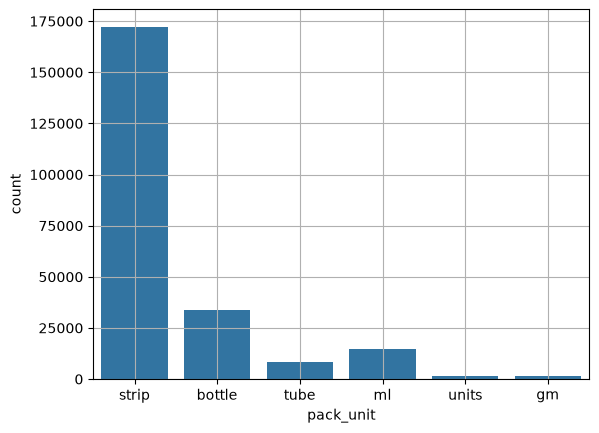

In [122]:
sns.countplot(x = df['pack_unit']) 
plt.grid()

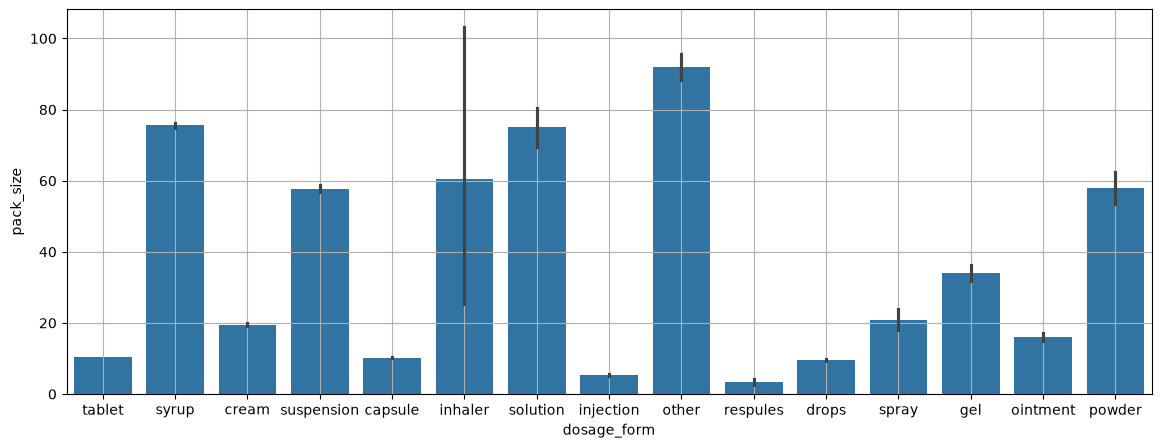

In [123]:
fig, ax = plt.subplots(1,1, figsize = (14,5))  
sns.barplot(x = df['dosage_form'], y = df['pack_size'], ax= ax)
plt.grid() 

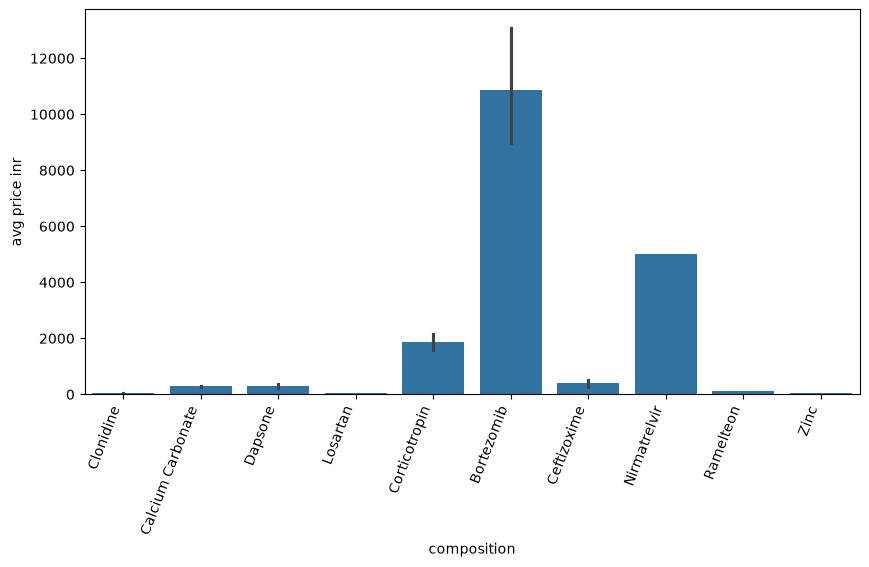

In [124]:
top_10_comps = df['primary_ingredient'].value_counts().sample(10).index

df_top_comps = df[df['primary_ingredient'].isin(top_10_comps)]

plt.figure(figsize=(10, 5))
sns.barplot(data=df_top_comps, x='primary_ingredient', y='price_inr')
plt.xticks(rotation=69, ha='right') 
plt.ylabel('avg price inr')
plt.xlabel('composition')
plt.show() 

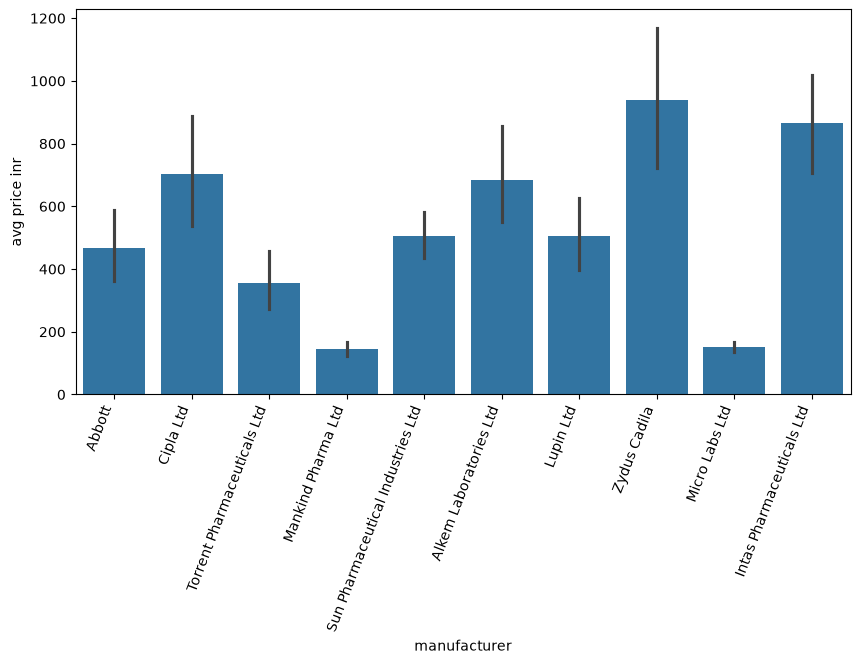

In [125]:
top_10_makers = df['manufacturer'].value_counts().head(10).index

df_top_makers = df[df['manufacturer'].isin(top_10_makers)]

plt.figure(figsize=(10, 5))
sns.barplot(data=df_top_makers, x='manufacturer', y='price_inr')
plt.xticks(rotation=69, ha='right') 
plt.ylabel('avg price inr')
plt.xlabel('manufacturer')
plt.show()

In [126]:
df[df['price_inr'] == 0.0]   

# All the medicines with price_inr = 0 are COVID-19 vaccines.

# So there are two possibilities:
# -> 0 means medicine was free 
# -> 0 means the price is unavailable or may be missing

# but model will not preform good when price is zero, so i decided to drop it 

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
35090,35091,Covishield Vaccine,Serum Institute Of India Ltd,0.0,False,injection,5.0,ml,1,ChAdOx1 nCoV-19 Corona Virus Vaccine,NaN,[{'name': 'ChAdOx1 nCoV-19 Corona Virus Vaccin...,other,vial of 5 ml Solution for Injection,Serum Institute Of India Ltd
37004,37005,Covaxin Vaccine,Bharat Biotech,0.0,False,injection,10.0,ml,2,Whole Virion,NaN,"[{'name': 'Whole Virion', 'strength': None, 'f...",other,vial of 10 ml Solution for Injection,Bharat Biotech
141999,142000,Moderna Vaccine,"ModernaTX, Inc",0.0,False,injection,5.0,ml,1,Messenger ribonucleic acid,NaN,"[{'name': 'Messenger ribonucleic acid', 'stren...",other,vial of 5 ml Solution for Injection,"ModernaTX, Inc"
204460,204461,Sputnik V Vaccine,Dr Reddy's Laboratories Ltd,0.0,False,injection,5.0,ml,1,Human adenovirus vector vaccine,NaN,"[{'name': 'Human adenovirus vector vaccine', '...",other,vial of 0.5 ml Injection,Dr Reddy's Laboratories Ltd


In [127]:
# pack_size                 22330 
# pack_unit                 22330 

df[df['pack_size'].isnull()].head()          

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
25,26,Asthalin 100mcg Inhaler,Cipla Ltd,157.85,False,inhaler,NaN,NaN,1,Salbutamol,NaN,"[{'name': 'Salbutamol', 'strength': None, 'ful...",bronchodilator,packet of 200 MDI Inhaler,Cipla Ltd
39,40,Arachitol 6L Injection,Abbott,407.76,False,injection,NaN,NaN,1,Vitamin D3,NaN,"[{'name': 'Vitamin D3', 'strength': None, 'ful...",other,packet of 6 injections,Abbott
53,54,Alex Cough Lozenges Lemon Ginger,Glenmark Pharmaceuticals Ltd,108.00,False,other,NaN,NaN,1,Dextromethorphan Hydrobromide,5mg,"[{'name': 'Dextromethorphan Hydrobromide', 'st...",other,strip of 10 lozenges,Glenmark Pharmaceuticals Ltd
66,67,Akt 4 Kit,Lupin Ltd,24.70,False,other,NaN,NaN,2,Isoniazid,300mg,"[{'name': 'Isoniazid', 'strength': '300mg', 'f...",other,packet of 1 Kit,Lupin Ltd
87,88,Aerocort Inhaler,Cipla Ltd,273.77,False,inhaler,NaN,NaN,2,Levosalbutamol,NaN,"[{'name': 'Levosalbutamol', 'strength': None, ...",corticosteroid,packet of 200 MDI Inhaler,Cipla Ltd


In [128]:
( df['pack_size'].isnull() == df['pack_unit'].isnull()).all()       # 'pack_size' and 'pack_unit' columns have missing values on the same row  

True

In [129]:
df[df['pack_size'].isnull()]['dosage_form'].value_counts()

dosage_form
injection     19794
capsule        1131
other           707
inhaler         250
tablet          165
respules         89
spray            79
solution         48
drops            16
suspension       14
syrup            12
gel               8
powder            7
ointment          5
cream             5
Name: count, dtype: int64

In [130]:
print(df[['pack_size']].isnull().mean() * 100)     # drop the rows is not good valuable 
print(df[['pack_unit']].isnull().mean() * 100) 

pack_size    8.792273
dtype: float64
pack_unit    8.792273
dtype: float64


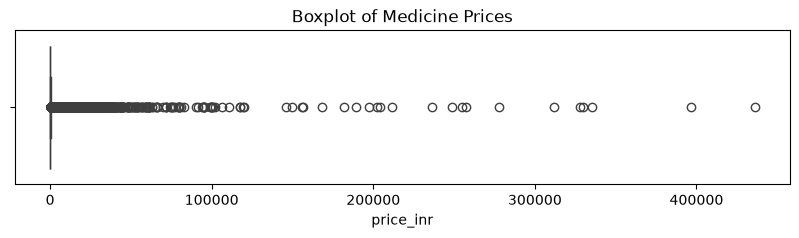

In [131]:
plt.figure(figsize=(10,2))
sns.boxplot(x=df['price_inr'])
plt.title("Boxplot of Medicine Prices")
plt.show()

In [132]:
df['price_inr'].max()

436000.0

In [133]:
df['price_inr'].describe(percentiles=[.25, .5, .75, .90, .95, .99])   # i have to drop the rows having price value above 99%ile 

count    253973.000000
mean        270.530844
std        3029.584134
min           0.000000
25%          48.000000
50%          79.000000
75%         140.000000
90%         254.000000
95%         430.500000
99%        2899.280000
max      436000.000000
Name: price_inr, dtype: float64

# Data cleaning

In [134]:
df_ml = df.copy() 

In [135]:
df_ml.sample(5)

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
60495,60496,Dextus Syrup,Positif Life sciences,48.0,False,syrup,100.0,bottle,2,Phenylpropanolamine,10mg,"[{'name': 'Phenylpropanolamine', 'strength': '...",antihistamine,bottle of 100 ml Syrup,Positif Life sciences
116719,116720,Ketonil 2% Shampoo,Ambit Bio Medix,154.5,False,other,100.0,bottle,1,Ketoconazole,NaN,"[{'name': 'Ketoconazole', 'strength': None, 'f...",other,bottle of 100 ml Shampoo,Ambit Bio Medix
24059,24060,Axozec 500 Tablet,M.M Pharma,62.0,False,tablet,3.0,strip,1,Azithromycin,500mg,"[{'name': 'Azithromycin', 'strength': '500mg',...",antibiotic,strip of 3 tablets,M.M Pharma
208488,208489,Sudon 4mg Tablet MD,Sunroxx Pharma,45.0,False,tablet,10.0,strip,1,Ondansetron,4mg,"[{'name': 'Ondansetron', 'strength': '4mg', 'f...",other,strip of 10 tablet md,Sunroxx Pharma
25504,25505,Asradic 75mg Injection,Asrawell Lifecare,14.9,False,injection,1.0,ml,1,Diclofenac,75mg,"[{'name': 'Diclofenac', 'strength': '75mg', 'f...",analgesic,vial of 1 ml Injection,Asrawell Lifecare


In [136]:
df_ml = df_ml[df_ml['price_inr'] > 0]                 # 0 price not possibe there should a valid price of a medicine   
df_ml = df_ml[df_ml['price_inr'] <= 3000] 
 
# droping unused columns
X = df_ml.drop(columns=['price_inr', 'product_id', 'brand_name']) 
y = df_ml['price_inr']

# handle missing values 
# Convert pack_size to numeric by extracting the numeric part
def extract_numeric_pack_size(val):
    if pd.isna(val):
        return -1
    val_str = str(val).strip()
    if val_str == '':
        return -1
    # Extract all digits and decimal points, then convert to float
    match = re.search(r'\d+\.?\d*', val_str)
    if match:
        try:
            return float(match.group())
        except:
            return -1
    return -1

X['pack_size'] = X['pack_size'].apply(extract_numeric_pack_size)
X['pack_size'] = X['pack_size'].astype(float)  # Ensure it's float type
X['pack_unit'] = X['pack_unit'].fillna('Unknown')
X['is_discontinued'] = X['is_discontinued'].astype(int)

In [137]:
import re

def clean_composition_text(text):

    if pd.isna(text):
        return ""
    text = str(text).lower()
    
    text = re.sub(r'[()\[\]]', '', text)             # Remove brackets
    text = re.sub(r'[-_]', ' ', text)                # Replaces hyphens with space
    text = re.sub(r'\s*/\s*', ' / ', text)           # Standardize slashes
    text = re.sub(r'\s+', ' ', text).strip()         # Remove extra spaces

    return text

X['cleaned_composition'] = X['primary_ingredient'].apply(clean_composition_text)

In [138]:
# verify 

comparison = X[
    ['primary_ingredient', 'cleaned_composition']
]

comparison.sample(5)

,primary_ingredient,cleaned_composition
83383,Imipenem,imipenem
147971,Methylcobalamin,methylcobalamin
126437,Lornoxicam,lornoxicam
223545,Piperacillin,piperacillin
168784,Diclofenac,diclofenac


In [139]:
print(X['primary_ingredient'].nunique())
print(X['cleaned_composition'].nunique())

1457
1456


In [140]:
X.drop(columns = ['primary_ingredient'],inplace = True)     

In [141]:
# Keep only the columns needed for the model
columns_to_keep = ['manufacturer', 'is_discontinued', 'dosage_form', 'pack_size', 'pack_unit', 'cleaned_composition']
X = X[columns_to_keep]

# Preprocessing

In [142]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder 
from sklearn.compose import ColumnTransformer  
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import HistGradientBoostingRegressor

In [143]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### 'manufacturer', 'cleaned_composition', 'dosage_form', 'pack_unit'

In [144]:
# define columntransformer
trf = ColumnTransformer(
    transformers=[
        
        ('ohe', OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore'), ['dosage_form', 'pack_unit']),
        
        ('tar_enc', TargetEncoder(target_type='continuous', smooth="auto"), ['manufacturer', 'cleaned_composition'])
    ], 
    remainder='passthrough'
)

trf.set_output(transform="pandas")

X_train_trf = trf.fit_transform(X_train, y_train)
X_test_trf = trf.transform(X_test)

In [145]:
# transform y for model training using PowerTransformer
pt = PowerTransformer(method='yeo-johnson')
y_train_transformed = pt.fit_transform(y_train.values.reshape(-1, 1)).ravel() 

In [146]:
# train randomforest model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X_train_trf, y_train_transformed)

# model evaluation 
y_pred_transformed_rf = model_rf.predict(X_test_trf)

# convert predictions into inr
y_pred_rupees_rf = pt.inverse_transform(y_pred_transformed_rf.reshape(-1, 1))  

#  MAE in inr
mae_rupees = mean_absolute_error(y_test, y_pred_rupees_rf)
print(f" MAE in rupee: {mae_rupees:.2f}")

 MAE in rupee: 52.15


In [147]:
# train HistGradientBoostingRegressor model
hgb_model = HistGradientBoostingRegressor(
    max_iter=100, 
    learning_rate=0.1, 
    random_state=42
)

hgb_model.fit(X_train_trf, y_train_transformed) 

y_pred_hgb_transformed = hgb_model.predict(X_test_trf)

y_pred_hgb_rupees = pt.inverse_transform(y_pred_hgb_transformed.reshape(-1, 1))

mae_hgb = mean_absolute_error(y_test, y_pred_hgb_rupees)
 
print(f"HistGradientBoosting MAE in rupee:    {mae_hgb:.2f}") 

HistGradientBoosting MAE in rupee:    49.77


In [158]:
# final model : HistGradientBoostingRegressor  
model = hgb_model

In [ ]:
# import joblib

# data = df.copy() 
# data['cleaned_composition'] = X['cleaned_composition'] 

# # This saves your trained Random Forest model's "brain" 
# joblib.dump(model, 'rf_model.joblib')

# # This saves the rules you made for the text columns  
# joblib.dump(trf, 'preprocessor.joblib')

# # This saves the math used for the prices
# joblib.dump(pt, 'power_transformer.joblib')

# # Save a clean copy of your dataset to search through later
# data.to_csv('cleaned_medicines.csv', index=False)

# print("DONE")                                               

DONE


In [159]:
import os
from pathlib import Path
import joblib

# 1. Prepare data
data = df.copy() 
data['cleaned_composition'] = X['cleaned_composition'] 

# 2. Save compressed model artifacts (compress=3 shrinks models by 80-90%)
joblib.dump(model, 'rf_model.joblib', compress=3)
joblib.dump(trf, 'preprocessor.joblib', compress=3)
joblib.dump(pt, 'power_transformer.joblib', compress=3)

# 3. Save the single clean dataset into the data/ directory (prevents duplicate files)
data_dir = Path("../data")
data_dir.mkdir(parents=True, exist_ok=True)
csv_target_path = data_dir / "cleaned_medicines.csv"
data.to_csv(csv_target_path, index=False)

# 4. Print size verification
print("✅ Artifacts saved successfully! Checking file sizes:")
for file_name in ['rf_model.joblib', 'preprocessor.joblib', 'power_transformer.joblib']:
    if os.path.exists(file_name):
        size_mb = os.path.getsize(file_name) / (1024 * 1024)
        print(f" - {file_name}: {size_mb:.2f} MB")

if csv_target_path.exists():
    print(f" - {csv_target_path}: {os.path.getsize(csv_target_path) / (1024 * 1024):.2f} MB")

✅ Artifacts saved successfully! Checking file sizes:
 - rf_model.joblib: 0.16 MB
 - preprocessor.joblib: 0.13 MB
 - power_transformer.joblib: 0.00 MB
 - ..\data\cleaned_medicines.csv: 72.76 MB


# o/p cross check

In [150]:
#model = model_rf
model = hgb_model

In [151]:
X_test.sample(5) 

,manufacturer,is_discontinued,dosage_form,pack_size,pack_unit,cleaned_composition
242471,Altrawell Biotech Pvt Ltd,0,injection,-1.0,Unknown,methylcobalamin
89628,Signova Pharma Pvt Ltd,0,tablet,10.0,strip,rosuvastatin
4412,Psychocare Health Pvt Ltd,0,tablet,10.0,strip,pregabalin
177186,Gary Pharmaceuticals Pvt Ltd,0,other,60.0,bottle,permethrin
85134,Chethana Pharmaceuticals,0,drops,5.0,bottle,ofloxacin


In [152]:
INDEX = 22280
PI = "Pioglitazone"

In [153]:
df.loc[[INDEX], :]   

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
22280,22281,Anzop D 30mg/40mg Tablet SR,Hos & Ins,69.0,False,tablet,10.0,strip,2,Domperidone,30mg,"[{'name': 'Domperidone', 'strength': '30mg', '...",antacid,strip of 10 tablet sr,Hos & Ins


In [154]:
y_test.loc[INDEX]      # sold price 

69.0

In [155]:
y_pred = model.predict(X_test_trf.loc[[INDEX], :])   

pt.inverse_transform(y_pred.reshape(-1, 1))        # fair sold price 

array([[70.23126278]])

In [156]:
df[df['primary_ingredient'] == PI].sample(5)

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
132444,132445,Lita 15mg Tablet,Intra Labs India Pvt Ltd,24.00,False,tablet,10.0,strip,1,Pioglitazone,15mg,"[{'name': 'Pioglitazone', 'strength': '15mg', ...",other,strip of 10 tablets,Intra Labs India Pvt Ltd
182813,182814,Piotrust 15mg Tablet,Trust Pharma,37.00,False,tablet,10.0,strip,1,Pioglitazone,15mg,"[{'name': 'Pioglitazone', 'strength': '15mg', ...",other,strip of 10 tablets,Trust Pharma
179566,179567,Pioglaz-M Tablet SR,East West Pharma,62.60,False,tablet,10.0,strip,2,Pioglitazone,15mg,"[{'name': 'Pioglitazone', 'strength': '15mg', ...",antidiabetic,strip of 10 tablet sr,East West Pharma
143898,143899,Mopaday HS 15mg/850mg Tablet ER,Wockhardt Ltd,95.00,True,tablet,10.0,strip,2,Pioglitazone,15mg,"[{'name': 'Pioglitazone', 'strength': '15mg', ...",antidiabetic,strip of 10 tablet er,Wockhardt Ltd
32318,32319,Betapride 30mg Tablet,Avinash Health Products Pvt Ltd,35.71,False,tablet,10.0,strip,1,Pioglitazone,30mg,"[{'name': 'Pioglitazone', 'strength': '30mg', ...",other,strip of 10 tablets,Avinash Health Products Pvt Ltd


In [157]:
df[df["primary_ingredient"] == PI].sort_values(by = 'price_inr') 

,product_id,brand_name,manufacturer,price_inr,is_discontinued,dosage_form,pack_size,pack_unit,num_active_ingredients,primary_ingredient,primary_strength,active_ingredients,therapeutic_class,packaging_raw,manufacturer_raw
177017,177018,Pioglitex 15mg Tablet,Zeelab Pharmacy Pvt Ltd,5.00,False,tablet,10.0,strip,1,Pioglitazone,15mg,"[{'name': 'Pioglitazone', 'strength': '15mg', ...",other,strip of 10 tablets,Zeelab Pharmacy Pvt Ltd
67710,67711,DavaIndia Pioglitazone 7.5mg Tablet,Davaindia Generic Pharmacy,8.00,False,tablet,10.0,strip,1,Pioglitazone,7.5mg,"[{'name': 'Pioglitazone', 'strength': '7.5mg',...",other,strip of 10 tablets,Davaindia Generic Pharmacy
181139,181140,Pioglitex 30 Tablet,Zeelab Pharmacy Pvt Ltd,10.00,False,tablet,10.0,strip,1,Pioglitazone,30mg,"[{'name': 'Pioglitazone', 'strength': '30mg', ...",other,strip of 10 tablets,Zeelab Pharmacy Pvt Ltd
67466,67467,DavaIndia Pioglitazone 15mg Tablet,Davaindia Generic Pharmacy,11.00,False,tablet,10.0,strip,1,Pioglitazone,15mg,"[{'name': 'Pioglitazone', 'strength': '15mg', ...",other,strip of 10 tablets,Davaindia Generic Pharmacy
175033,175034,Pio 15mg Tablet,Systopic Laboratories Pvt Ltd,11.27,True,tablet,10.0,strip,1,Pioglitazone,15mg,"[{'name': 'Pioglitazone', 'strength': '15mg', ...",other,strip of 10 tablets,Systopic Laboratories Pvt Ltd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
174534,174535,Pioglar-G Tablet,Sun Pharmaceutical Industries Ltd,137.00,False,tablet,10.0,strip,2,Pioglitazone,15mg,"[{'name': 'Pioglitazone', 'strength': '15mg', ...",antidiabetic,strip of 10 tablets,Sun Pharmaceutical Industries Ltd
175342,175343,Piopar 15 Tablet,Mitoch Pharma Pvt Ltd,140.00,False,tablet,30.0,strip,1,Pioglitazone,15mg,"[{'name': 'Pioglitazone', 'strength': '15mg', ...",other,strip of 30 tablets,Mitoch Pharma Pvt Ltd
134786,134787,Mopaday Forte Tablet ER,Wockhardt Ltd,158.00,False,tablet,10.0,strip,2,Pioglitazone,15mg,"[{'name': 'Pioglitazone', 'strength': '15mg', ...",antidiabetic,strip of 10 tablet er,Wockhardt Ltd
135177,135178,Mopaday 15 Tablet ER,Wockhardt Ltd,171.00,False,tablet,15.0,strip,2,Pioglitazone,15mg,"[{'name': 'Pioglitazone', 'strength': '15mg', ...",antidiabetic,strip of 15 tablet er,Wockhardt Ltd
